In [60]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt

In [61]:

env = gym.make("CarRacing-v3", render_mode="rgb_array", lap_complete_percent=0.95, domain_randomize=False, continuous=False)
env

<TimeLimit<OrderEnforcing<PassiveEnvChecker<CarRacing<CarRacing-v3>>>>>

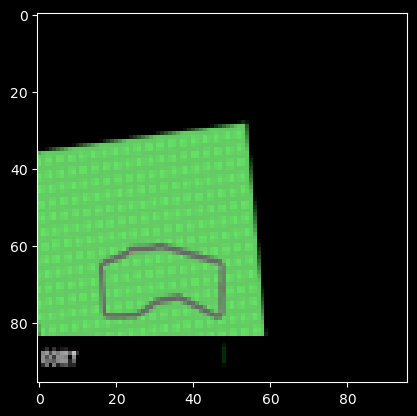

In [62]:
obs, info = env.reset()

plt.imshow(obs)

In [63]:
pos = env.unwrapped.car.hull.position
angle = env.unwrapped.car.hull.angle
print("car position:", float(pos[0]), float(pos[1]), "angle:", float(angle))

car position: 219.0359344482422 -51.74185562133789 angle: -0.11004768311977386

### DQN on Discrete CarRacing: what this does

1. Builds a **discrete-action** CarRacing environment (`continuous=False`).  
2. Wraps it with **Monitor** logging (episode rewards over time).  
3. Trains a **DQN (CnnPolicy)** model on pixel input.  
4. Loads logged rewards and plots the **learning curve** (episode reward vs timesteps).

This is intentionally minimal and easy to modify.

Using cpu device

/opt/homebrew/Caskroom/miniforge/base/envs/gym/lib/python3.10/site-packages/stable_baselines3/common/buffers.py:242
: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 5.53GB > 
1.40GB
  warnings.warn(

Logging to ./tb_logs/DQN_2

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1e+03    |
|    ep_rew_mean      | -56.3    |
|    exploration_rate | 0.406    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 201      |
|    time_elapsed     | 19       |
|    total_timesteps  | 4000     |
----------------------------------

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 1e+03    |
|    ep_rew_mean      | -58.9    |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 114      |
|    time_elapsed     | 69       |
|    total_timesteps  | 8000     |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0693   |
|    n_updates        | 749      |
----------------------------------

...

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 987      |
|    ep_rew_mean      | -37.1    |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 24       |
|    fps              | 78       |
|    time_elapsed     | 300      |
|    total_timesteps  | 23699    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.19     |
|    n_updates        | 4674     |
----------------------------------

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 989      |
|    ep_rew_mean      | -31.3    |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 28       |
|    fps              | 76       |
|    time_elapsed     | 359      |
|    total_timesteps  | 27699    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.00481  |
|    n_updates        | 5674     |
----------------------------------

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 969      |
|    ep_rew_mean      | -17.5    |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 32       |
|    fps              | 75       |
|    time_elapsed     | 409      |
|    total_timesteps  | 31002    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.00304  |
|    n_updates        | 6500     |
----------------------------------

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32,000/32,000  [ 0:07:03 < 0:00:00 , 68 it/s ]

/opt/homebrew/Caskroom/miniforge/base/envs/gym/lib/python3.10/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

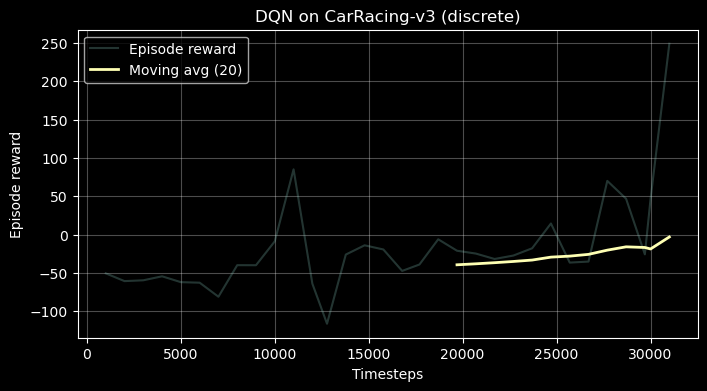

In [64]:
# Minimal DQN training on discrete CarRacing + learning curve
from pathlib import Path

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from stable_baselines3 import DQN
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common.vec_env import VecTransposeImage

# In discrete mode, action space is Discrete(5)
# (noop, left, right, gas, brake)
def make_discrete_env():
    return gym.make(
        "CarRacing-v3",
        render_mode="rgb_array",
        continuous=False,
        lap_complete_percent=0.95,
        domain_randomize=False,
    )

log_dir = Path("./logs/dqn_discrete")
log_dir.mkdir(parents=True, exist_ok=True)

venv = make_vec_env(
    make_discrete_env,
    n_envs=1,
    monitor_dir=str(log_dir),
    seed=42,
)
venv = VecTransposeImage(venv)  # HWC -> CHW for CnnPolicy

model = DQN(
    policy="CnnPolicy",
    env=venv,
    learning_rate=1e-4,
    buffer_size=100_000,
    learning_starts=5_000,
    batch_size=32,
    train_freq=4,
    target_update_interval=1_000,
    exploration_fraction=0.20,
    exploration_final_eps=0.05,
    verbose=1,
    tensorboard_log="./tb_logs",
    seed=42,
)

# Increase for better results (e.g., 300_000 to 1_000_000)
total_timesteps = 32_000
model.learn(total_timesteps=total_timesteps, progress_bar=True)
model.save("dqn_carracing_discrete")
venv.close()

# Learning curve from Monitor logs
x, y = ts2xy(load_results(str(log_dir)), "timesteps")

if len(y) == 0:
    print("No episode rewards logged yet. Train for more timesteps.")
else:
    window = 20
    if len(y) >= window:
        y_smooth = np.convolve(y, np.ones(window) / window, mode="valid")
        x_smooth = x[window - 1 :]
    else:
        y_smooth = y
        x_smooth = x

    plt.figure(figsize=(8, 4))
    plt.plot(x, y, alpha=0.25, label="Episode reward")
    plt.plot(x_smooth, y_smooth, linewidth=2, label=f"Moving avg ({window})")
    plt.xlabel("Timesteps")
    plt.ylabel("Episode reward")
    plt.title("DQN on CarRacing-v3 (discrete)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


In [ ]:
# Play one episode with the trained DQN agent
from pathlib import Path

import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from IPython.display import Video, display
from stable_baselines3 import DQN

MODEL_PATH = "dqn_carracing_discrete"  # loads dqn_carracing_discrete.zip
LIVE_WINDOW = True  # True: open a game window, False: save and display mp4 in notebook
MAX_STEPS = 2_000

if LIVE_WINDOW:
    env_play = gym.make(
        "CarRacing-v3",
        render_mode="human",
        continuous=False,
        lap_complete_percent=0.95,
        domain_randomize=False,
    )
    model_play = DQN.load(MODEL_PATH)

    obs, info = env_play.reset(seed=123)
    ep_reward = 0.0

    for _ in range(MAX_STEPS):
        action, _ = model_play.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env_play.step(action)
        ep_reward += reward
        if terminated or truncated:
            break

    env_play.close()
    print(f"Episode reward (human render): {ep_reward:.1f}")
else:
    video_dir = Path("./videos/agent_play")
    video_dir.mkdir(parents=True, exist_ok=True)

    env_play = gym.make(
        "CarRacing-v3",
        render_mode="rgb_array",
        continuous=False,
        lap_complete_percent=0.95,
        domain_randomize=False,
    )
    env_play = RecordVideo(
        env_play,
        video_folder=str(video_dir),
        episode_trigger=lambda episode_id: True,
        disable_logger=True,
    )
    model_play = DQN.load(MODEL_PATH)

    obs, info = env_play.reset(seed=123)
    ep_reward = 0.0

    for _ in range(MAX_STEPS):
        action, _ = model_play.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env_play.step(action)
        ep_reward += reward
        if terminated or truncated:
            break

    env_play.close()

    latest_video = sorted(video_dir.glob("*.mp4"))[-1]
    print(f"Episode reward (recorded): {ep_reward:.1f}")
    print(f"Saved video: {latest_video}")
    display(Video(str(latest_video), embed=True))

/opt/homebrew/Caskroom/miniforge/base/envs/gym/lib/python3.10/site-packages/stable_baselines3/common/buffers.py:242
: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 5.53GB > 
1.27GB
  warnings.warn(

2026-04-08 11:09:21.394 python[53698:44311849] +[IMKClient subclass]: chose IMKClient_Legacy
2026-04-08 11:09:21.395 python[53698:44311849] +[IMKInputSession subclass]: chose IMKInputSession_Legacy


Episode reward (human render): -34.8

: 